# **Project Part 1: YOLOv3**

Slides: [Google slide](https://docs.google.com/presentation/d/1CvQ1aq5LrImusv2QyhMOJkJovM6WooTVRXGhuN6opuE/)

Supplementary Information: [Google slide](https://docs.google.com/presentation/d/156K25Uwx_vkoDmLIzjFvL2RBRLKCh-GPz9WDxALKSKI/)

Video: [Youtube](https://youtu.be/gy9BXmGg894)

Objectives:
* Use YOLOv3 to practice the object detection task.
* Get familiar with PyTorch & YOLOv3.

If any questions, please contact the TA via email:
* Hung-Shuo Chang: jonathanc@iis.sinica.edu.tw

This notebook:

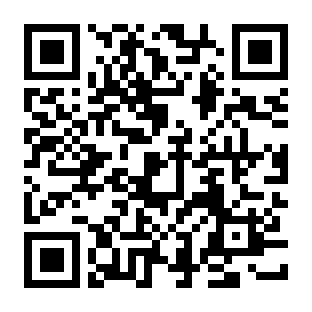

## **Introduction**

YOLO is a series of real-time object detection method.

YOLOv3 ([paper](https://arxiv.org/pdf/1804.02767.pdf)):
1. Anchor Based
2. Darknet-53
3. Feature Pyramid Networks (FPN)



### **Darknet-53**

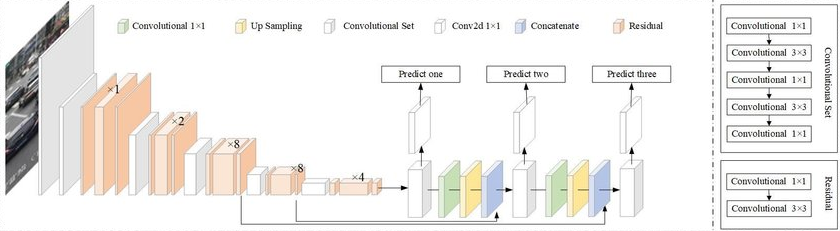

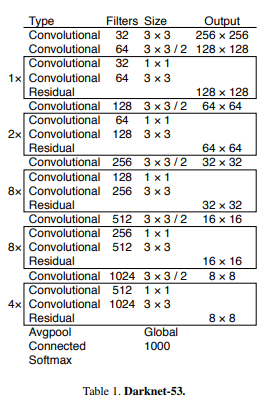

# **Report**

## **Do it yourself**

Please use the YOLOv3 and another dataset to train your own object detection model.

Dataset: [Car Object Detection](https://www.kaggle.com/datasets/sshikamaru/car-object-detection)

You have to convert the annotations in csv to YOLOv3 format. ([ref](https://github.com/ultralytics/yolov3/wiki/Train-Custom-Data))

You also need to adjust hyperparameters to get better performance.

**Hint**:
1. hyp yaml file in *data/hyps* folder
  + search for a good learning rate (**lr0**) for the optimizer you use
  + **iou_t** should not be too large or too low

2. train.py
  + training by using more **epochs**

3. val.py & detect.py (if necessary)
  + try to adjust the **conf-thres** & **iou-thres** for better results and scores




---

# **Environment Checking**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# [修改點 1] 雲端備份設定 + 命名策略
# [TRY3] 架構簡化：只檢查 Drive；EXP 命名由 SYNC 格統一衍生（單一實作在 car_tools.exp）

from pathlib import Path

assert Path("/content/drive/MyDrive").exists(), "❌ 請先執行 drive.mount('/content/drive')"
print("EXP 命名由 SYNC 格統一衍生（開新實驗請設 NEW_EXP=1 後跑 SYNC 格）")

Please make sure your runtime type is ***GPU*** or ***TPU***

Check GPU by using the following command:

In [ ]:
!nvidia-smi

# **Setup YOLOv3**

This section is used to setup YOLOv3 and its environment.

## **Download Project**

We use [ultralytics/yolov3](https://github.com/ultralytics/yolov3), which is pytorch version of YOLOv3 and is made by the author of YOLOv5.

Use `git clone` command for download project from github.

In [ ]:
# [TRY3-skip] 已 clone 則跳過（Run-all 重跑免報錯）

!test -d /content/yolov3_pytorch || git clone https://github.com/ws6125/yolov3_pytorch.git /content/yolov3_pytorch

## **Install required packages**

In [ ]:
# [TRY3] repo：提供 car_tools（需先 push 本 repo，並設定 PROJECT_REPO_URL；已存在則跳過 clone）

%cd /content/yolov3_pytorch
%pip install -r requirements.txt
%pip install -q openpyxl
%pip install -q 'albumentations<2'
%env WANDB_DISABLED=true

import os as _os
import sys as _sys
from pathlib import Path as _Path
PROJECT_DIR = _Path("/content/yolov3-car-detection")
if not PROJECT_DIR.exists():
    try:
      from google.colab import userdata as _ud
      _ud_url = _ud.get("PROJECT_REPO_URL")
    except Exception:
      _ud_url = ""

    if not PROJECT_DIR.exists():
      _url = _ud_url or _os.environ.get("PROJECT_REPO_URL", "")
    assert _url, "Secret 與 env 都沒有 PROJECT_REPO_URL，請檢查 Colab Secrets 名稱拼字後重跑本格"

    import subprocess as _sp
    _r = _sp.run(["git", "clone", _url, str(PROJECT_DIR)])
    assert _r.returncode == 0, "git clone 作品 repo 失敗"
if "/content/yolov3-car-detection/tools" not in _sys.path:
    _sys.path.insert(0, "/content/yolov3-car-detection/tools")

# 每一步改這一行 EXP_YAML 即可
_os.environ["EXP_YAML"] = "/content/yolov3-car-detection/configs/experiments/car_640_e12.yaml"
%env PYTHONPATH=/content/yolov3-car-detection/tools
print("PROJECT_DIR =", PROJECT_DIR, "EXP_YAML =", _os.environ["EXP_YAML"])

In [ ]:
# [TRY3] EXP 同步格：$EXP_YAML 唯一真相；衍生 EXP_NAME/BACKUP_DIR（單一實作在 car_tools.exp）
# 優先順序：yaml > pointer 檔 > os.environ 手設值；DRIVE_ROOT 固定；NEW_EXP 只留 env 通道

import os as _osync
from pathlib import Path as _Psync
from car_tools.run import load_experiment
from car_tools.exp import apply_to_env, open_experiment
_EYAML = _osync.environ.get("EXP_YAML", "")
assert _EYAML, "EXP_YAML 未設定（請先跑 repo 設定格指派 EXP_YAML）"
assert _Psync(_EYAML).exists(), f"EXP_YAML 指向的檔案不存在：{_EYAML!r}（請檢查拼字）"
_ETAG = str(load_experiment(_EYAML)["exp"])
_NEW_EXP = _osync.environ.get("NEW_EXP", "0") == "1"
_INFO = open_experiment(_ETAG, new_exp=_NEW_EXP)
apply_to_env(_INFO["exp_name"], _INFO["backup_dir"])
print(f"EXP_YAML={_EYAML} tag={_ETAG} NEW_EXP={int(_NEW_EXP)}")
print(f"EXP_NAME={_INFO['exp_name']}")
print(f"BACKUP_DIR={_INFO['backup_dir']}")
if _NEW_EXP:
    print("⚠️ 已開新實驗：請把 NEW_EXP 設回 0，否則下次重跑會再開新")

# **Download Dataset**

## **Dataset: Car Object Detection (Kaggle)**

Car Object Detection ([Kaggle: sshikamaru/car-object-detection](https://www.kaggle.com/datasets/sshikamaru/car-object-detection)) as the Part-1 practice set.

Raw zip lives on Drive (`MyDrive/YOLO_Data/car-object-detection.zip`, NOT in git); unzipped in Colab to `../datasets/car-raw`. Annotations are a CSV (`image,xmin,ymin,xmax,ymax`, exact header confirmed by `head()` in the next cell), converted to YOLO format in Cell 26–27. Single class: `car` (nc=1).


In [ ]:
# [TRY-重寫] Drive Kaggle zip 解到 ../datasets/car-raw＋檢查

from pathlib import Path

raw_dir = Path('../datasets/car-raw')   # Kaggle 解壓目的地
ZIP_DRIVE = Path('/content/drive/MyDrive/YOLO_Data/car-object-detection.zip')
ZIP_LOCAL = Path('car-object-detection.zip')  # 手動上傳到 yolov3_pytorch/ 時的備援位置

assert Path('/content/drive/MyDrive').exists(), '請先跑 drive.mount'
zip_path = ZIP_DRIVE if ZIP_DRIVE.exists() else ZIP_LOCAL
assert zip_path.exists(), f'找不到 {ZIP_DRIVE}（或備援 {ZIP_LOCAL}）：請先把 Kaggle zip 放到 Drive/YOLO_Data/'
print('zip =', zip_path, f'{zip_path.stat().st_size/1e6:.1f} MB')

raw_dir.mkdir(parents=True, exist_ok=True)
# [TRY3-skip] 訓練圖齊全＋csv 存在則跳過解壓（zip 更新請手動刪除 car-raw 再跑）
_have_imgs = sorted((raw_dir / 'data' / 'training_images').glob('*')) if (raw_dir / 'data' / 'training_images').is_dir() else []
_have_csvs = list(raw_dir.rglob('*.csv'))
if len(_have_imgs) >= 1000 and len(_have_csvs) >= 1:
    print(f'SKIP unzip：training_images 已有 {len(_have_imgs)} 張＋{len(_have_csvs)} 個 csv')
else:
    import zipfile
    with zipfile.ZipFile(zip_path) as z:
        print('zip 內容預覽（前20）：')
        for n in z.namelist()[:20]:
            print('  ', n)
        z.extractall(raw_dir)
    print('解壓完成 →', raw_dir.resolve())

# ---- 檢查 ----
import subprocess
print(subprocess.run(['ls', '-R', str(raw_dir)], capture_output=True, text=True).stdout[:3000])
csvs = sorted(raw_dir.rglob('*.csv'))
print('CSVs:', [str(c) for c in csvs])
assert csvs, 'car-raw 下找不到 csv，請檢查 zip 結構'
import pandas as pd
for c in csvs:
    df0 = pd.read_csv(c, nrows=5)
    print('---', c, 'columns=', list(df0.columns), '---')
    print(df0.head(3).to_string())
print('Done!（下一步做清洗＋轉YOLO）')

## **Adjust Annotation Format**

Convert annotations to YOLOv3 format:

In [ ]:
# [TRY3] 轉換流程改呼叫 car_tools

from pathlib import Path
from car_tools.convert import split_and_convert

# [TRY3-skip] manifest 吻合自動跳過（強制重跑：暫時拿掉 skip_done）

stats = split_and_convert(raw_dir, Path("../datasets/car"), seed=42, skip_done=True)

Modify the path of dataset in **yaml file**:

In [ ]:
# [TRY-重寫] 新建 data/car.yaml

import os
from pathlib import Path
import yaml

assert Path('data').is_dir(), "找不到 data/，請確認已 %cd yolov3_pytorch"
yolo_dir = Path('../datasets/car')
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    assert (yolo_dir / sub).is_dir(), f"找不到 {yolo_dir/sub}，請先跑「標註轉換」格"

yaml_file = os.path.join(os.getcwd(), 'data/car.yaml')
yaml_dict = {
    'path': str(yolo_dir),  # ../datasets/car
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['car'],
}
with open(yaml_file, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_dict, f, sort_keys=False, default_flow_style=False)

with open(yaml_file, encoding='utf-8') as f:
    check = yaml.safe_load(f)
assert check.get('nc') == 1 and check.get('names') == ['car'], f"car.yaml 內容異常：{check}"
assert check.get('train') == 'images/train' and check.get('val') == 'images/val', f"car.yaml 內容異常：{check}"
print("yaml 已新建：", yaml_file)
print(check)

# **Use YOLOv3**

The following steps will show you how to use YOLOv3:
1. Training
2. Validation
3. Inference
4. Visualize



## **Training**

Train a YOLOv3 model on the dataset.

You can also set `--weights` parameter to use a pre-train model.

In [ ]:
# [TRY3] 訓練改走配置：$EXP_YAML 唯一入口；epochs/lr/hyp 全由 yaml 來（--skip-done：已完成自動跳過）

!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage train --skip-done

In [ ]:
# [修改點 3] 備份 train 產出到雲端（完整 runs/）
# 策略：本地跑 → 完整複製，含 weights/best.pt、last.pt、results.csv、曲線圖、hyp/opt.yaml

!set -e; : "${EXP_NAME:?❌ EXP_NAME 未設定，請先跑 [修改點 1]}"; : "${BACKUP_DIR:?❌ BACKUP_DIR 未設定}"; test -d "runs/train/$EXP_NAME" || { echo "❌ 找不到 runs/train/$EXP_NAME（請先完成訓練）"; exit 1; }; rm -rf "$BACKUP_DIR/train/$EXP_NAME"; mkdir -p "$BACKUP_DIR/train"; cp -r "runs/train/$EXP_NAME" "$BACKUP_DIR/train/"; echo "--- train backup ---"; ls -lh "runs/train/$EXP_NAME/weights/"; du -sh "runs/train/$EXP_NAME" "$BACKUP_DIR/train/$EXP_NAME"

## **Validation**

Validate the model by using validation set.

You should change the `--weight` parameter to your own model.

In [ ]:
# [TRY3] 驗證改走配置（val.txt 由 run.py tee 落盤，供紀錄表類別明細；--skip-done：已完成自動跳過）

!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage val --skip-done

In [ ]:
# [修改點 5] 備份 val 產出到雲端

!set -e; : "${EXP_NAME:?❌ EXP_NAME 未設定}"; : "${BACKUP_DIR:?❌ BACKUP_DIR 未設定}"; test -d "runs/val/$EXP_NAME" || { echo "❌ 找不到 runs/val/$EXP_NAME（請先完成驗證）"; exit 1; }; rm -rf "$BACKUP_DIR/val/$EXP_NAME"; mkdir -p "$BACKUP_DIR/val"; cp -r "runs/val/$EXP_NAME" "$BACKUP_DIR/val/"; echo "--- val backup ---"; ls -R "runs/val/$EXP_NAME" | head -n 30; du -sh "runs/val/$EXP_NAME" "$BACKUP_DIR/val/$EXP_NAME"

In [ ]:
# [TRY3] 掃參改走配置（iou/conf 網格由 yaml 的 sweep 段來；快取/Excel/備份邏輯在 car_tools.sweep；逐項快取本來就會跳過）

!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage sweep --skip-done


## **Inference**

Inference images by using YOLOv3 model.

You should change the `--weight` parameter to your own model.

`--source` provides image, video, and directory. ([ref](https://colab.research.google.com/github/ultralytics/yolov3/blob/master/tutorial.ipynb#scrollTo=4JnkELT0cIJg))

In [ ]:
# [TRY3] 推論改走配置（source/conf 由 yaml 的 detect 段來；--skip-done：已完成自動跳過）

!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage detect --skip-done

In [ ]:
# [修改點 7] 備份 detect 產出 + 總驗證

!set -e; : "${EXP_NAME:?❌ EXP_NAME 未設定}"; : "${BACKUP_DIR:?❌ BACKUP_DIR 未設定}"; test -d "runs/detect/$EXP_NAME" || { echo "❌ 找不到 runs/detect/$EXP_NAME（請先完成推論）"; exit 1; }; rm -rf "$BACKUP_DIR/detect/$EXP_NAME"; mkdir -p "$BACKUP_DIR/detect"; cp -r "runs/detect/$EXP_NAME" "$BACKUP_DIR/detect/"; echo "=== backup tree ==="; ls -R "$BACKUP_DIR" | head -n 60; echo "=== sizes ==="; du -sh "$BACKUP_DIR" "$BACKUP_DIR"/*

## **Visualize**

In [ ]:
# [修改點 8] 視覺化：路徑改為 $EXP_NAME 對應圖

import os
from PIL import Image
from pathlib import Path

exp = os.environ.get("EXP_NAME", "")
assert exp, "EXP_NAME 未設定（請先跑 SYNC 格衍生 EXP_NAME）"
cands = sorted(Path(f"runs/detect/{exp}").glob("*.jpg"))
print("EXP_NAME =", exp, f"，找到 {len(cands)} 張")

assert cands, (
    f"找不到偵測結果圖（runs/detect/{exp} 內無 jpg）；"
    "請確認推論已完成、且本格 EXP_NAME 與 $EXP_YAML 對應實驗一致；"
    f"runs/detect 內容：{[p.name for p in Path('runs/detect').iterdir()] if Path('runs/detect').exists() else '(無 runs/detect 目錄)'}"
)
img = Image.open(cands[0])

display(img)

In [ ]:
# [TRY3] 紀錄改走配置（update_workbook 參數由 yaml 的 val/detect 段來；note 自動帶 exp+hyp_override）

!echo "EXP_YAML=$EXP_YAML"
!python -m car_tools.run --exp "$EXP_YAML" --stage record